In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import cohen_kappa_score
from src.model import logistic_regression
from src.model import random_forest
from src.untiles import classification_reports
from src.untiles import classification_evaluation_plots

In [2]:
X_train=pd.read_csv('C:\\Users\\dawit\\PycharmProjects\\supernova\\data\\X_train.csv')
X_test=pd.read_csv('C:\\Users\\dawit\\PycharmProjects\\supernova\\data\\X_test.csv')
y_train=pd.read_csv('C:\\Users\\dawit\\PycharmProjects\\supernova\\data\\y_train.csv')
y_test=pd.read_csv('C:\\Users\\dawit\\PycharmProjects\\supernova\\data\\y_test.csv')

In [3]:
y_train=y_train['SN']
y_test=y_test['SN']

In [4]:
print(X_test.shape)
print(y_test.shape)
print(X_train.shape)
print(y_train.shape)

(747, 15)
(747,)
(2987, 15)
(2987,)


In [5]:
lr_p=Pipeline([('poly',PolynomialFeatures(degree=2)),('pip_lr',logistic_regression(max_iter=10000,C=100))])
random_forest=random_forest()

In [6]:
voting_classifier=VotingClassifier(estimators=[('lr_p',lr_p),('random_forest',random_forest)],voting='soft').fit(X_train,y_train)

In [7]:
train_voting_preds=voting_classifier.predict(X_train)
train_voting_proba=voting_classifier.predict_proba(X_train)[:,1]
cohen_kappa_score(y_train,train_voting_preds)

0.8885155517339941

In [8]:
classification_reports(y_train,train_voting_preds)

,0,1,accuracy,macro avg,weighted avg
precision,0.955289,0.934085,0.947104,0.944687,0.947062
recall,0.958425,0.929249,0.947104,0.943837,0.947104
f1-score,0.956854,0.931661,0.947104,0.944258,0.947079
support,1828.000000,1159.000000,0.947104,2987.000000,2987.000000


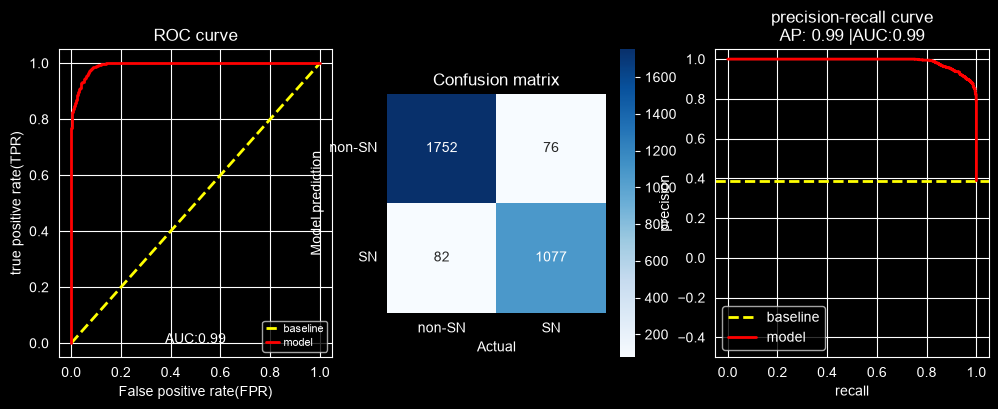

In [9]:
classification_evaluation_plots(y_train,train_voting_preds,train_voting_proba)

In [10]:
test_voting_preds=voting_classifier.predict(X_test)
test_voting_preds_proba=voting_classifier.predict_proba(X_test)[:,1]

In [11]:
classification_reports(y_test,test_voting_preds)

,0,1,accuracy,macro avg,weighted avg
precision,0.845475,0.748299,0.807229,0.796887,0.807749
recall,0.838074,0.758621,0.807229,0.798348,0.807229
f1-score,0.841758,0.753425,0.807229,0.797591,0.807465
support,457.000000,290.000000,0.807229,747.000000,747.000000


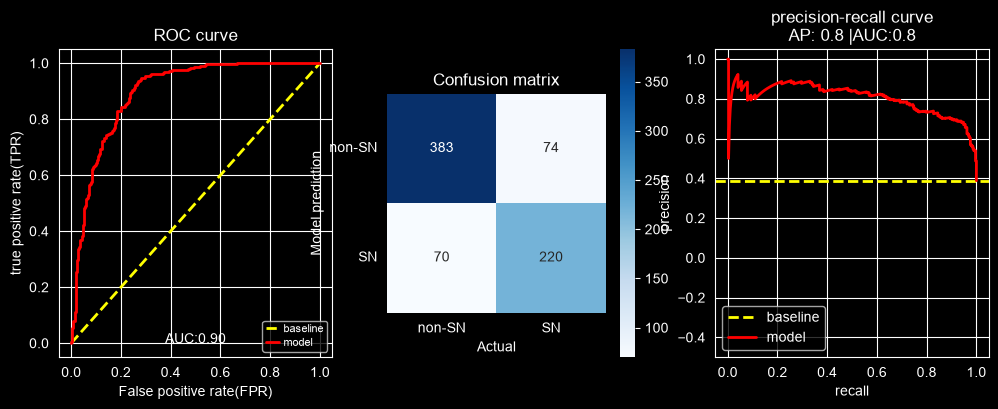

In [12]:
classification_evaluation_plots(y_test,test_voting_preds,test_voting_preds_proba)

In [13]:
cohen_kappa_score(y_test,test_voting_preds)

0.5951950867052023

In [14]:
training_results = pd.DataFrame({
    "Model":[ "Decision Tree","KNN","Polynomial LR (C=100)","Random Forest","Soft Voting"],
    "Accuracy":[1.00, 0.851021,0.825578,1.00,0.947104],
    "Macro F1": [1.00,0.844223,0.816337,1.00,0.944258],
    "SN Precision":[1.00,0.796512,0.775475,1.00,0.934085],
    "SN Recall": [1.00,0.827437,0.774806,1.00,0.929249],
    "SN F1": [1.00,0.811680, 0.775140, 1.00,0.931661],
    "ROC AUC": [1.00,0.93,0.91,1.00,0.99],"PR AP":[1.00,0.87,0.84,1.00,0.99],
    "Cohen's Kappa": [1.000000,0.688519,0.632674,1.000000,0.888516]
})
training_results.head()

,Model,Accuracy,Macro F1,SN Precision,SN Recall,SN F1,ROC AUC,PR AP,Cohen's Kappa
0,Decision Tree,1.000000,1.000000,1.000000,1.000000,1.000000,1.00,1.00,1.000000
1,KNN,0.851021,0.844223,0.796512,0.827437,0.811680,0.93,0.87,0.688519
2,Polynomial LR (C=100),0.825578,0.816337,0.775475,0.774806,0.775140,0.91,0.84,0.632674
3,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000,1.00,1.00,1.000000
4,Soft Voting,0.947104,0.944258,0.934085,0.929249,0.931661,0.99,0.99,0.888516


In [15]:
test_results = pd.DataFrame({
    "Model":["Decision Tree","KNN","Polynomial LR (C=100)","Random Forest",
"Soft Voting"],
    "Accuracy":[0.761714,0.764391,0.800535,0.820616,0.807229],
    "Macro F1":[ 0.761714,0.753502,0.789909,0.811648,0.797591],
    "SN Precision":[0.689189,0.690000,0.743945,0.765306,0.748299],
    "SN Recall":[0.703448,0.713793,0.741379,0.775862,0.758621],
    "SN F1":[ 0.696246, 0.701695, 0.742660, 0.770548, 0.753425],
    "ROC AUC":[0.75,0.84,0.88,0.89,0.90],
    "PR AP":[0.60,0.69,0.78,0.79,0.80],
    "Cohen's Kappa":[0.505251,0.507097,0.579819,0.601818,0.595195]})
test_results.head()

,Model,Accuracy,Macro F1,SN Precision,SN Recall,SN F1,ROC AUC,PR AP,Cohen's Kappa
0,Decision Tree,0.761714,0.761714,0.689189,0.703448,0.696246,0.75,0.60,0.505251
1,KNN,0.764391,0.753502,0.690000,0.713793,0.701695,0.84,0.69,0.507097
2,Polynomial LR (C=100),0.800535,0.789909,0.743945,0.741379,0.742660,0.88,0.78,0.579819
3,Random Forest,0.820616,0.811648,0.765306,0.775862,0.770548,0.89,0.79,0.601818
4,Soft Voting,0.807229,0.797591,0.748299,0.758621,0.753425,0.90,0.80,0.595195


In [16]:
training_results.to_csv("C:\\Users\\dawit\\PycharmProjects\\supernova\\results\\training_results.csv", index=False)
test_results.to_csv("C:\\Users\\dawit\\PycharmProjects\\supernova\\results\\test_results.csv", index=False)